# 03 â€” Feature Engineering
Rolling stats over prev1-3, irregular/symptom counts, ordinal interactions. Target-free -> no leakage.

In [1]:

import sys, os
from pathlib import Path
root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
from src.features import run_features
from src.config import ENGINEERED_CSV, ENGINEERED_NUMERIC

eng = run_features()
eng[ENGINEERED_NUMERIC].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
cycle_mean_3,20000.0,29.129,3.667,15.0,27.333,29.000,31.000,42.000
cycle_std_3,20000.0,0.899,0.803,0.0,0.471,0.816,0.943,8.994
cycle_range_3,20000.0,2.055,1.898,0.0,1.000,2.000,2.000,22.000
cycle_slope_3,20000.0,0.011,1.136,-9.5,-0.500,0.000,0.500,11.000
period_mean_3,20000.0,4.745,1.168,1.0,4.000,4.667,5.667,8.333
period_std_3,20000.0,0.433,0.283,0.0,0.471,0.471,0.471,1.700
period_range_3,20000.0,0.953,0.654,0.0,1.000,1.000,1.000,4.000
period_slope_3,20000.0,0.001,0.451,-2.0,-0.500,0.000,0.500,1.500
irregular_count_3,20000.0,0.270,0.779,0.0,0.000,0.000,0.000,3.000
cramps_count_3,20000.0,1.877,0.863,0.0,1.000,2.000,3.000,3.000


## New-feature correlations with targets

,next_cycle_length,next_period_length,next_is_irregular
cycle_mean_3,0.879,0.014,-0.009
cycle_std_3,-0.006,0.017,0.063
cycle_range_3,-0.006,0.017,0.063
cycle_slope_3,0.094,0.024,0.031
period_mean_3,0.016,0.823,-0.011
period_std_3,-0.004,0.004,-0.010
period_range_3,-0.006,0.004,-0.012
period_slope_3,0.018,0.007,0.006
irregular_count_3,-0.013,-0.008,0.797
cramps_count_3,0.015,0.230,0.066


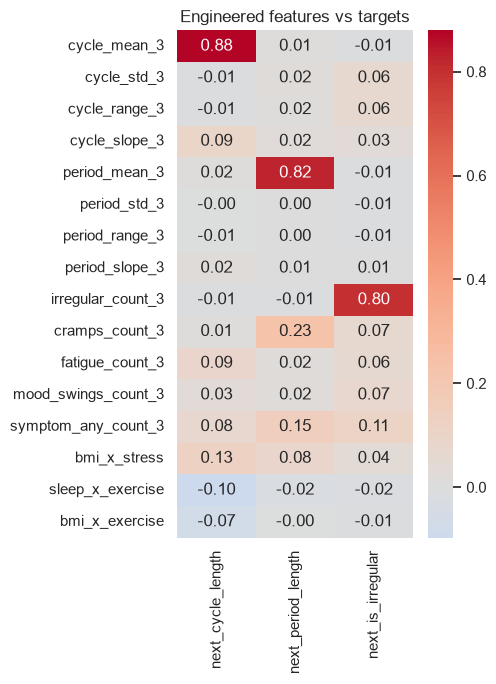

engineered shape: (20000, 46)
saved -> E:\NAVYA_MODEL\data\processed\engineered.csv


In [3]:
from src.config import FIGURES_DIR

targets = ["next_cycle_length", "next_period_length", "next_is_irregular"]
corr = eng[ENGINEERED_NUMERIC + targets].corr(numeric_only=True)[targets].drop(index=targets)
display(corr.round(3))
plt.figure(figsize=(5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Engineered features vs targets")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "feat_engineered_correlations.png", dpi=150); plt.show()
print("engineered shape:", eng.shape)
print("saved ->", ENGINEERED_CSV)
